In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_cores = multiprocessing.cpu_count()
print(num_cores)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


16


In [2]:
# Configuration and paths
corr_method = 'pearson'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [ ]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6coding_PRScorr.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [4]:
alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc'])
alof

id,region,loftee_hc
str,str,i8
"""chr1:169795116:G:C""","""ENSG00000000460""",0
"""chr1:169798959:G:A""","""ENSG00000000460""",0
"""chr1:169798959:G:C""","""ENSG00000000460""",0
"""chr1:169798959:G:GT""","""ENSG00000000460""",0
"""chr1:169798959:G:T""","""ENSG00000000460""",0
…,…,…
"""chr7:151061966:C:T""","""ENSG00000288608""",0
"""chr7:151061967:GA:G""","""ENSG00000288608""",1
"""chr7:151061968:A:G""","""ENSG00000288608""",0


In [5]:
alof['region'].value_counts(sort=True)

region,count
str,u64
"""ENSG00000143631""",9263
"""ENSG00000008710""",8573
"""ENSG00000081853""",8384
"""ENSG00000178209""",8265
"""ENSG00000151914""",7460
…,…
"""ENSG00000072694""",73
"""ENSG00000164032""",67
"""ENSG00000162188""",59


In [6]:
gnames = pl.read_csv('/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv',
    separator='\t',
    null_values=['.', 'NA'],
).filter(
    pl.col('transcript_type') == 'protein_coding'
).select(['gene', 'gene_id']).unique().rename({
    'gene': 'gene_name',
    'gene_id': 'region'
}).drop_nulls()

gnames

gene_name,region
str,str
"""SLC7A4""","""ENSG00000099960"""
"""WNT7A""","""ENSG00000154764"""
"""MACROD1""","""ENSG00000133315"""
"""NOTCH1""","""ENSG00000148400"""
"""ZNF77""","""ENSG00000175691"""
…,…
"""SPATA31A1""","""ENSG00000204849"""
"""LGR4""","""ENSG00000205213"""
"""PIN1""","""ENSG00000127445"""


In [7]:
alof_gp = appv.join(alof, on='id', how='inner').join(gnames, on='region', how='left')
alof_gp

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,gene_name
str,str,u32,f32,f32,str,i8,str
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null,"""ENSG00000157933""",0,"""SKI"""
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646,"""ENSG00000130939""",0,"""UBE4B"""
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165,"""ENSG00000157881""",0,"""PANK4"""
…,…,…,…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null,"""ENSG00000196576""",0,"""PLXNB2"""


In [39]:
# 1. Aggregate to get correlation (r) and number of pairs (n)
lofcorr_df = (
    alof_gp.lazy()
    .group_by(["region", "gene_name", "phenotype"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.col("loftee_hc").sum().alias("n_plof"),
        # Add this line to count the number of non-null pairs used for the correlation, same as n_variants
        (pl.col("mean_pheno_value").is_not_null() & pl.col("loftee_hc").is_not_null()).sum().alias("n_variants_nonull"),
        pl.corr("mean_pheno_value", "loftee_hc").alias("correlation"),
    )
    .filter(
        (pl.col("n_variants_nonull") > 2) &
        (pl.col("n_plof") > 0)
    )  
    
    # 2. Compute the t-statistic and p-value on the aggregated results
    .with_columns(
        # Calculate the t-statistic from r and n
        t_stat=pl.col("correlation") * ((pl.col("n_variants_nonull") - 2) / (1 - pl.col("correlation")**2))**0.5,
    )
    .with_columns(
        # Calculate the two-tailed p-value from the t-statistic
        p_value=pl.struct(["t_stat", "n_variants_nonull"]).map_elements(
            lambda x: (
                stats.t.sf(np.abs(x["t_stat"]), df=x["n_variants_nonull"] - 2) * 2
                if x["t_stat"] is not None else None
            ),
            return_dtype=pl.Float64
        )
    )
).collect(engine='streaming')

lofcorr_df

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value
str,str,str,u64,i64,u64,f32,f64,f64
"""ENSG00000185666""","""SYN3""","""creatinine_enzymatic_in_urine_…",568,32,568,0.040618,0.96712,0.333897
"""ENSG00000012048""","""BRCA1""","""trunk_fatfree_mass_int""",1168,138,1168,0.029938,1.022758,0.306635
"""ENSG00000064932""","""SBNO2""","""sitting_height_int""",1771,85,1771,0.05198,2.189204,0.028712
"""ENSG00000105376""","""ICAM5""","""weight_int""",744,30,744,-0.037066,-1.010368,0.312648
"""ENSG00000120438""","""TCP1""","""phosphate_int""",520,6,520,0.023421,0.533202,0.594122
…,…,…,…,…,…,…,…,…
"""ENSG00000160229""","""ZNF66""","""platelet_distribution_width_in…",155,23,155,0.088526,1.099322,0.273354
"""ENSG00000173542""","""MOB1B""","""red_blood_cell_erythrocyte_cou…",146,10,146,0.151335,1.837177,0.068245
"""ENSG00000048405""","""ZNF800""","""basophill_count_int""",362,9,362,0.034539,0.655719,0.512424


In [44]:
lofcorr_df.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
)

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value
str,str,str,u64,i64,u64,f32,f64,f64
"""ENSG00000169047""","""IRS1""","""basal_metabolic_rate_int""",1053,57,1053,-0.149431,-4.899424,0.000001


In [45]:
lofcorr_df.filter(pl.col('p_value') < 0.05/gnames['region'].n_unique())

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value
str,str,str,u64,i64,u64,f32,f64,f64
"""ENSG00000162733""","""DDR2""","""leg_fatfree_mass_left_int""",511,19,511,-0.221506,-5.124695,4.2389e-7
"""ENSG00000173064""","""HECTD4""","""leg_fat_percentage_left_int""",2693,79,2693,0.114921,6.00125,2.2210e-9
"""ENSG00000164061""","""BSN""","""arm_fat_percentage_right_int""",3229,61,3229,0.084416,4.81255,0.000002
"""ENSG00000146112""","""PPP1R18""","""body_mass_index_bmi_impedance_…",525,33,525,0.214551,5.023592,6.9713e-7
"""ENSG00000187045""","""TMPRSS6""","""haemoglobin_concentration_int""",710,56,710,-0.202709,-5.508101,5.0794e-8
…,…,…,…,…,…,…,…,…
"""ENSG00000171587""","""DSCAM""","""creactive_protein_int""",1379,41,1379,0.138641,5.194841,2.3570e-7
"""ENSG00000128849""","""CGNL1""","""gamma_glutamyltransferase_int""",1034,79,1034,0.160893,5.23686,1.9790e-7
"""ENSG00000056586""","""RC3H2""","""fluid_intelligence_score_int""",429,13,429,-0.288486,-6.225976,1.1455e-9


In [69]:
from statsmodels.stats.multitest import multipletests

# The helper function to correct p-values
def apply_correction(pvals: pl.Series, method: str) -> pl.Series:
    if pvals.is_empty():
        return pvals
        
    _, pvals_corrected, _, _ = multipletests(
        pvals=pvals.to_numpy(),
        alpha=0.05,
        method=method
    )
    
    result = pl.Series(name=pvals.name, values=pvals_corrected, dtype=pl.Float64)
    return result

# Apply the correction using .map_batches() and .alias()
final_df = lofcorr_df.with_columns(
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='bonferroni'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bonf"),

    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='holm'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_holm"),
    
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='fdr_bh'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bh")
)
# View the final results
final_df

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,str,str,u64,i64,u64,f32,f64,f64,f64,f64,f64
"""ENSG00000185666""","""SYN3""","""creatinine_enzymatic_in_urine_…",568,32,568,0.040618,0.96712,0.333897,1.0,1.0,0.867708
"""ENSG00000012048""","""BRCA1""","""trunk_fatfree_mass_int""",1168,138,1168,0.029938,1.022758,0.306635,1.0,1.0,0.761657
"""ENSG00000064932""","""SBNO2""","""sitting_height_int""",1771,85,1771,0.05198,2.189204,0.028712,1.0,1.0,0.243892
"""ENSG00000105376""","""ICAM5""","""weight_int""",744,30,744,-0.037066,-1.010368,0.312648,1.0,1.0,0.762672
"""ENSG00000120438""","""TCP1""","""phosphate_int""",520,6,520,0.023421,0.533202,0.594122,1.0,1.0,0.916349
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000160229""","""ZNF66""","""platelet_distribution_width_in…",155,23,155,0.088526,1.099322,0.273354,1.0,1.0,0.765086
"""ENSG00000173542""","""MOB1B""","""red_blood_cell_erythrocyte_cou…",146,10,146,0.151335,1.837177,0.068245,1.0,1.0,0.54077
"""ENSG00000048405""","""ZNF800""","""basophill_count_int""",362,9,362,0.034539,0.655719,0.512424,1.0,1.0,0.884604


In [71]:
final_df.filter(pl.col('p_adj_holm') < 0.05)

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,str,str,u64,i64,u64,f32,f64,f64,f64,f64,f64
"""ENSG00000004939""","""SLC4A1""","""cystatin_c_int""",663,22,663,0.166264,4.334963,0.000017,0.033869,0.033667,0.002421
"""ENSG00000162733""","""DDR2""","""leg_fatfree_mass_left_int""",511,19,511,-0.221506,-5.124695,4.2389e-7,0.000852,0.00085,0.000142
"""ENSG00000163631""","""ALB""","""alanine_aminotransferase_int""",434,36,434,0.207556,4.410017,0.000013,0.026257,0.026192,0.004376
"""ENSG00000173064""","""HECTD4""","""leg_fat_percentage_left_int""",2693,79,2693,0.114921,6.00125,2.2210e-9,0.000004,0.000004,0.000003
"""ENSG00000164061""","""BSN""","""arm_fat_percentage_right_int""",3229,61,3229,0.084416,4.81255,0.000002,0.003134,0.003128,0.000627
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000056586""","""RC3H2""","""fluid_intelligence_score_int""",429,13,429,-0.288486,-6.225976,1.1455e-9,0.000002,0.000002,0.000001
"""ENSG00000162733""","""DDR2""","""leg_predicted_mass_right_int""",511,19,511,-0.208958,-4.820719,0.000002,0.003804,0.003787,0.00038
"""ENSG00000169047""","""IRS1""","""sitting_height_int""",1060,57,1060,-0.166704,-5.499306,4.7797e-8,0.000096,0.000096,0.00001


In [70]:
final_df.filter(pl.col('p_adj_bh') < 0.05)

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,str,str,u64,i64,u64,f32,f64,f64,f64,f64,f64
"""ENSG00000112077""","""RHAG""","""hand_grip_strength_right_int""",321,17,321,-0.206044,-3.760766,0.000201,0.405182,0.399944,0.015007
"""ENSG00000004939""","""SLC4A1""","""cystatin_c_int""",663,22,663,0.166264,4.334963,0.000017,0.033869,0.033667,0.002421
"""ENSG00000084774""","""CAD""","""reticulocyte_count_int""",1603,80,1603,-0.094003,-3.778027,0.000164,0.32904,0.326582,0.020565
"""ENSG00000196712""","""NF1""","""hand_grip_strength_left_int""",1630,131,1630,-0.081076,-3.282108,0.001052,1.0,1.0,0.044513
"""ENSG00000283632""","""EXOC3L2""","""mean_corpuscular_haemoglobin_i…",768,30,768,0.124156,3.463023,0.000564,1.0,1.0,0.030613
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000118007""","""STAG1""","""creatinine_enzymatic_in_urine_…",631,7,631,0.173503,4.418443,0.000012,0.023542,0.02353,0.011771
"""ENSG00000177853""","""ZNF518A""","""standing_height_int""",1168,58,1168,0.103586,3.556266,0.000391,0.786797,0.75941,0.01095
"""ENSG00000132507""","""EIF5A""","""weight_impedance_int""",164,3,164,-0.25413,-3.344345,0.001025,1.0,1.0,0.043846


## Single gene plot

Pearson r: -0.14943072199821472, p-value: 1.1124075181356423e-06


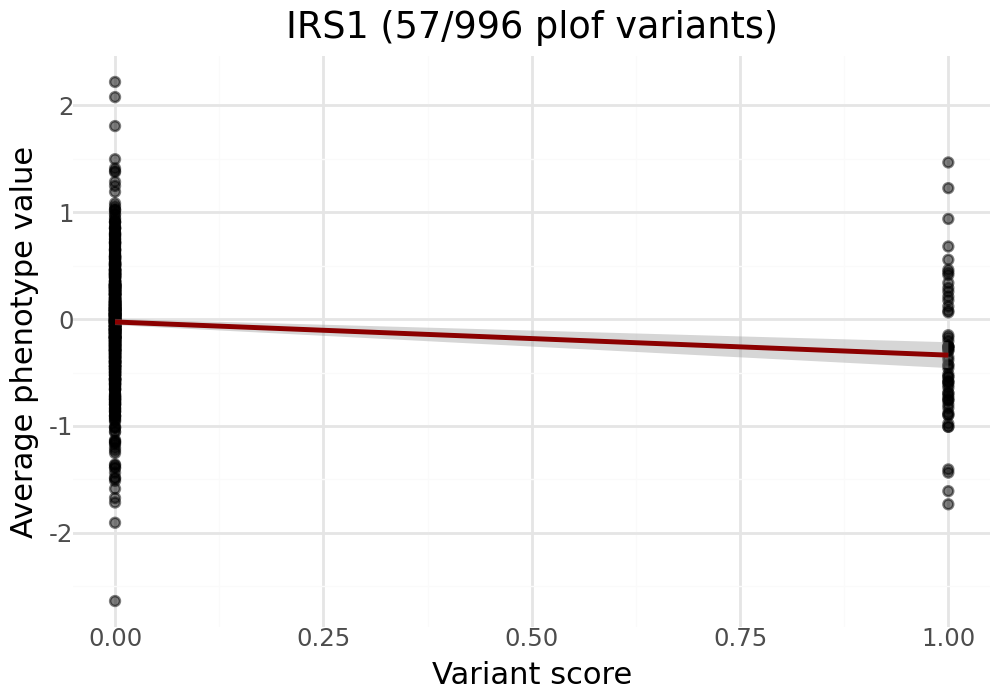

In [72]:
from scipy import stats

method = 'pearson'
# gene_name = 'GCK'
# phenotype = 'glycated_haemoglobin_hba1c_int'
gene_name = "IRS1"
phenotype = "basal_metabolic_rate_int"

# Filter your main dataframe
sc_df = alof_gp.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
).drop_nulls(subset=['loftee_hc', 'mean_pheno_value'])

lof0 = sc_df.filter(pl.col('loftee_hc') == 0).shape[0]
lof1 = sc_df.filter(pl.col('loftee_hc') == 1).shape[0]

# Check if enough data remains for calculation
if len(sc_df) >= 2:
    pearson_r, pearson_p = stats.pearsonr(
        sc_df['loftee_hc'], 
        sc_df['mean_pheno_value']
    )
else:
    pearson_r, pearson_p = np.nan, np.nan

print(f"Pearson r: {pearson_r}, p-value: {pearson_p}")
# Scatter plot
(
    ggplot(sc_df, aes(x='loftee_hc', y='mean_pheno_value')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='Variant score',
        y="Average phenotype value",
        title=f"{gene_name} ({lof1}/{lof0} plof variants)"
    ) +
    theme(figure_size=(5, 3.5))
)